In [1]:
import pandas as pd


train_data_path = 'balanced_train_data.csv'
validation_data_path = 'validation_data.csv'
test_data_path = 'test_data.csv'

train_data = pd.read_csv(train_data_path)
validation_data = pd.read_csv(validation_data_path)
test_data = pd.read_csv(test_data_path)

# Display the first few rows of the train dataset
train_data.head()

,Customer_Age,Dependent_count,Education_Level,Income_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,...,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Gender_M,Marital_Status_Married,Marital_Status_Single,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver,Attrition_Flag
0,0.489362,1.0,4,1,0.604651,0.4,0.166667,0.666667,0.094617,0.000000,...,0.131783,0.192663,0.000000,0.0,1.0,0.0,0.0,0.0,0.0,1
1,0.531915,0.8,2,0,0.674419,0.4,0.333333,0.500000,1.000000,0.700437,...,0.240310,0.294035,0.051051,1.0,0.0,1.0,0.0,0.0,0.0,1
2,0.255319,0.6,2,2,0.348837,0.4,0.166667,0.333333,0.096975,0.667461,...,0.193798,0.186782,0.362362,1.0,1.0,0.0,0.0,0.0,0.0,1
3,0.680851,0.2,2,4,0.813953,0.6,0.500000,0.166667,0.071973,0.747716,...,0.449612,0.248950,0.493493,0.0,0.0,1.0,0.0,0.0,0.0,1
4,0.191489,0.8,2,2,0.209302,0.4,0.500000,0.500000,0.220049,0.285658,...,0.379845,0.166620,0.082082,1.0,0.0,1.0,0.0,0.0,0.0,1


In [2]:
validation_data.head()

,Customer_Age,Dependent_count,Education_Level,Income_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,...,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Gender_M,Marital_Status_Married,Marital_Status_Single,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver,Attrition_Flag
0,0.361702,1.0,2,4,0.534884,0.4,0.333333,0.333333,0.000000,0.000000,...,0.426357,0.133576,0.000000,1.0,0.0,1.0,0.0,0.0,0.0,1
1,0.808511,0.2,2,4,1.000000,0.4,0.166667,0.833333,0.034697,0.000000,...,0.426357,0.163820,0.000000,1.0,0.0,1.0,0.0,0.0,0.0,1
2,0.340426,0.2,2,4,0.534884,0.6,0.500000,0.166667,0.065201,0.756456,...,0.573643,0.181182,0.530531,0.0,0.0,1.0,0.0,0.0,0.0,1
3,0.234043,0.4,5,1,0.325581,0.0,0.500000,0.333333,0.048725,1.000000,...,0.503876,0.258471,0.825826,0.0,0.0,1.0,0.0,0.0,0.0,1
4,0.297872,0.6,2,4,0.418605,0.6,0.333333,0.500000,0.017465,0.388558,...,0.527132,0.266032,0.485485,0.0,0.0,1.0,0.0,0.0,0.0,1


In [3]:
test_data.head()

,Customer_Age,Dependent_count,Education_Level,Income_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,...,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Gender_M,Marital_Status_Married,Marital_Status_Single,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver,Attrition_Flag
0,0.212766,0.4,2,4,0.302326,0.4,0.500000,0.333333,0.000000,0.000000,...,0.604651,0.244189,0.000000,0.0,1.0,0.0,0.0,0.0,0.0,1
1,0.340426,0.4,2,4,0.534884,1.0,0.166667,0.666667,0.037448,1.000000,...,0.511628,0.226827,0.940941,0.0,0.0,1.0,0.0,0.0,0.0,1
2,0.446809,0.6,2,0,0.534884,0.4,0.333333,0.500000,0.240606,0.315852,...,0.682171,0.162700,0.085085,1.0,1.0,0.0,0.0,0.0,0.0,1
3,0.404255,1.0,2,1,0.465116,0.2,0.333333,0.500000,0.000000,0.000000,...,0.573643,0.220386,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1
4,0.446809,0.4,2,4,0.534884,0.4,0.500000,0.500000,0.037448,0.552245,...,0.410853,0.130216,0.519520,0.0,0.0,1.0,0.0,0.0,0.0,1


In [4]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

X_train = train_data.drop('Attrition_Flag', axis=1)
y_train = train_data['Attrition_Flag']

# Assuming X_train and y_train are already defined and preprocessed
logreg = LogisticRegression()
rfe = RFE(estimator=logreg, n_features_to_select=10, step=1)
rfe.fit(X_train, y_train)  # Use the already scaled and balanced data

# Print the selected features
selected_features_rfe = X_train.columns[rfe.support_]
print("Selected features through RFE:", selected_features_rfe)


/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_ite

Selected features through RFE: Index(['Customer_Age', 'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1',
       'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1',
       'Card_Category_Platinum'],
      dtype='object')


In [5]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Fit Random Forest to the training data
rf = RandomForestClassifier()
rf.fit(X_train, y_train)  # Use the already scaled and balanced data

# Get feature importances
importances = rf.feature_importances_
importance_series = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)

# Print the feature importances
print("Feature importances through Random Forest:")
print(importance_series)

Feature importances through Random Forest:
Total_Trans_Ct              0.199371
Total_Trans_Amt             0.191348
Total_Ct_Chng_Q4_Q1         0.104385
Total_Revolving_Bal         0.097130
Total_Relationship_Count    0.059805
Avg_Utilization_Ratio       0.050197
Total_Amt_Chng_Q4_Q1        0.046933
Marital_Status_Married      0.044161
Marital_Status_Single       0.025927
Avg_Open_To_Buy             0.025847
Credit_Limit                0.024678
Gender_M                    0.023912
Customer_Age                0.023502
Months_Inactive_12_mon      0.020165
Months_on_book              0.017665
Contacts_Count_12_mon       0.011896
Dependent_count             0.009531
Education_Level             0.009072
Income_Category             0.008497
Card_Category_Silver        0.004092
Card_Category_Gold          0.001307
Card_Category_Platinum      0.000577
dtype: float64


In [6]:
# Extract common features identified by both RFE and Random Forest methods
common_features = [
    'Total_Relationship_Count', 'Months_Inactive_12_mon', 
    'Total_Revolving_Bal', 'Total_Trans_Ct', 
    'Total_Ct_Chng_Q4_Q1', 'Gender_M', 
    'Marital_Status_Married'
]

# Preparing the dataframes for model building
train_common_features = train_data[common_features + ['Attrition_Flag']]
validation_common_features = validation_data[common_features + ['Attrition_Flag']]
test_common_features = test_data[common_features + ['Attrition_Flag']]

train_common_features.head()


,Total_Relationship_Count,Months_Inactive_12_mon,Total_Revolving_Bal,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Gender_M,Marital_Status_Married,Attrition_Flag
0,0.4,0.166667,0.000000,0.131783,0.192663,0.0,1.0,1
1,0.4,0.333333,0.700437,0.240310,0.294035,1.0,0.0,1
2,0.4,0.166667,0.667461,0.193798,0.186782,1.0,1.0,1
3,0.6,0.500000,0.747716,0.449612,0.248950,0.0,0.0,1
4,0.4,0.500000,0.285658,0.379845,0.166620,1.0,0.0,1


Metrics for Model with All Features:
{'Accuracy': 0.857847976307996, 'Precision': 0.9578469520103762, 'Recall': 0.8688235294117647, 'F1 Score': 0.9111659469463294, 'ROC AUC': 0.9152490075784915}

Metrics for Model with Important Features:
{'Accuracy': 0.8346495557749259, 'Precision': 0.9516876240900066, 'Recall': 0.8458823529411764, 'F1 Score': 0.8956711304889443, 'ROC AUC': 0.8868928184770841}


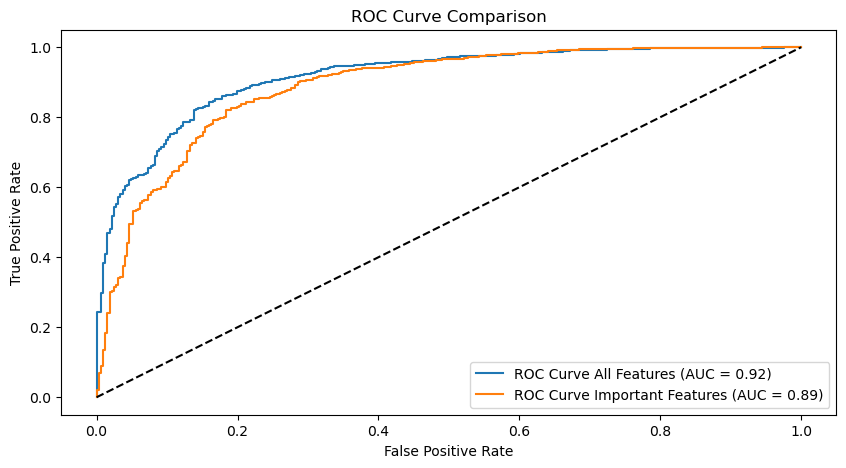

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Prepare features and labels
X_train_all = train_data.drop(columns=['Attrition_Flag'])
y_train_all = train_data['Attrition_Flag']
X_test_all = test_data.drop(columns=['Attrition_Flag'])
y_test_all = test_data['Attrition_Flag']

X_train_important = train_common_features.drop(columns=['Attrition_Flag'])
y_train_important = train_common_features['Attrition_Flag']
X_test_important = test_common_features.drop(columns=['Attrition_Flag'])
y_test_important = test_common_features['Attrition_Flag']

# Build models
model_all = LogisticRegression(max_iter=1000)
model_important = LogisticRegression(max_iter=1000)

model_all.fit(X_train_all, y_train_all)
model_important.fit(X_train_important, y_train_important)

# Predictions
y_preds_all = model_all.predict(X_test_all)
y_probs_all = model_all.predict_proba(X_test_all)[:, 1]
y_preds_important = model_important.predict(X_test_important)
y_probs_important = model_important.predict_proba(X_test_important)[:, 1]

# Metrics
metrics_all = {
    'Accuracy': accuracy_score(y_test_all, y_preds_all),
    'Precision': precision_score(y_test_all, y_preds_all),
    'Recall': recall_score(y_test_all, y_preds_all),
    'F1 Score': f1_score(y_test_all, y_preds_all),
    'ROC AUC': roc_auc_score(y_test_all, y_probs_all)
}

metrics_important = {
    'Accuracy': accuracy_score(y_test_important, y_preds_important),
    'Precision': precision_score(y_test_important, y_preds_important),
    'Recall': recall_score(y_test_important, y_preds_important),
    'F1 Score': f1_score(y_test_important, y_preds_important),
    'ROC AUC': roc_auc_score(y_test_important, y_probs_important)
}

# Print metrics
print("Metrics for Model with All Features:")
print(metrics_all)
print("\nMetrics for Model with Important Features:")
print(metrics_important)

# ROC Curve
fpr_all, tpr_all, _ = roc_curve(y_test_all, y_probs_all)
fpr_important, tpr_important, _ = roc_curve(y_test_important, y_probs_important)

plt.figure(figsize=(10, 5))
plt.plot(fpr_all, tpr_all, label=f'ROC Curve All Features (AUC = {metrics_all["ROC AUC"]:.2f})')
plt.plot(fpr_important, tpr_important, label=f'ROC Curve Important Features (AUC = {metrics_important["ROC AUC"]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()


Metrics for Decision Tree Model with All Features:
{'Accuracy': 0.9299111549851925, 'Precision': 0.9636904761904762, 'Recall': 0.9523529411764706, 'F1 Score': 0.9579881656804733, 'ROC AUC': 0.8826181883796462}

Metrics for Decision Tree Model with Important Features:
{'Accuracy': 0.8790720631786771, 'Precision': 0.9385171790235082, 'Recall': 0.9158823529411765, 'F1 Score': 0.927061625483775, 'ROC AUC': 0.8013704438830749}


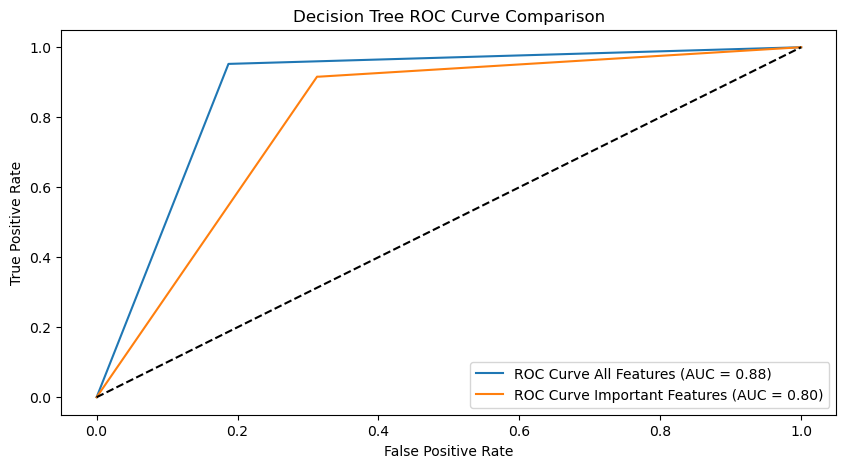

In [8]:
from sklearn.tree import DecisionTreeClassifier

# Build Decision Tree models
dt_model_all = DecisionTreeClassifier()
dt_model_important = DecisionTreeClassifier()

dt_model_all.fit(X_train_all, y_train_all)
dt_model_important.fit(X_train_important, y_train_important)

# Predictions
dt_y_preds_all = dt_model_all.predict(X_test_all)
dt_y_probs_all = dt_model_all.predict_proba(X_test_all)[:, 1]
dt_y_preds_important = dt_model_important.predict(X_test_important)
dt_y_probs_important = dt_model_important.predict_proba(X_test_important)[:, 1]

# Metrics for Decision Tree
dt_metrics_all = {
    'Accuracy': accuracy_score(y_test_all, dt_y_preds_all),
    'Precision': precision_score(y_test_all, dt_y_preds_all),
    'Recall': recall_score(y_test_all, dt_y_preds_all),
    'F1 Score': f1_score(y_test_all, dt_y_preds_all),
    'ROC AUC': roc_auc_score(y_test_all, dt_y_probs_all)
}

dt_metrics_important = {
    'Accuracy': accuracy_score(y_test_important, dt_y_preds_important),
    'Precision': precision_score(y_test_important, dt_y_preds_important),
    'Recall': recall_score(y_test_important, dt_y_preds_important),
    'F1 Score': f1_score(y_test_important, dt_y_preds_important),
    'ROC AUC': roc_auc_score(y_test_important, dt_y_probs_important)
}

# Print metrics
print("Metrics for Decision Tree Model with All Features:")
print(dt_metrics_all)
print("\nMetrics for Decision Tree Model with Important Features:")
print(dt_metrics_important)

# ROC Curve for Decision Tree
dt_fpr_all, dt_tpr_all, _ = roc_curve(y_test_all, dt_y_probs_all)
dt_fpr_important, dt_tpr_important, _ = roc_curve(y_test_important, dt_y_probs_important)

plt.figure(figsize=(10, 5))
plt.plot(dt_fpr_all, dt_tpr_all, label=f'ROC Curve All Features (AUC = {dt_metrics_all["ROC AUC"]:.2f})')
plt.plot(dt_fpr_important, dt_tpr_important, label=f'ROC Curve Important Features (AUC = {dt_metrics_important["ROC AUC"]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Decision Tree ROC Curve Comparison')
plt.legend()
plt.show()


Metrics for Random Forest Model with All Features:
{'Accuracy': 0.9595261599210266, 'Precision': 0.9747652582159625, 'Recall': 0.9770588235294118, 'F1 Score': 0.9759106933019978, 'ROC AUC': 0.9864335979790688}

Metrics for Random Forest Model with Important Features:
{'Accuracy': 0.9220138203356367, 'Precision': 0.9545990566037735, 'Recall': 0.9523529411764706, 'F1 Score': 0.9534746760895171, 'ROC AUC': 0.938435582822086}


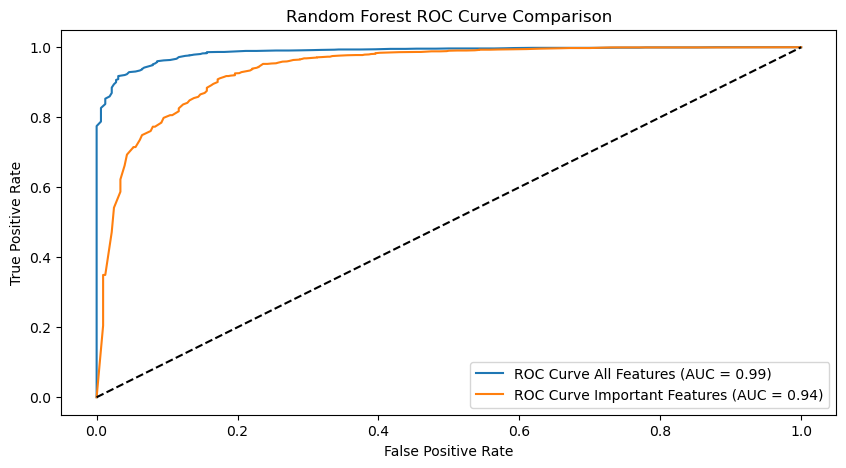

In [9]:
from sklearn.ensemble import RandomForestClassifier

# Build Random Forest models
rf_model_all = RandomForestClassifier()
rf_model_important = RandomForestClassifier()

rf_model_all.fit(X_train_all, y_train_all)
rf_model_important.fit(X_train_important, y_train_important)

# Predictions
rf_y_preds_all = rf_model_all.predict(X_test_all)
rf_y_probs_all = rf_model_all.predict_proba(X_test_all)[:, 1]
rf_y_preds_important = rf_model_important.predict(X_test_important)
rf_y_probs_important = rf_model_important.predict_proba(X_test_important)[:, 1]

# Metrics for Random Forest
rf_metrics_all = {
    'Accuracy': accuracy_score(y_test_all, rf_y_preds_all),
    'Precision': precision_score(y_test_all, rf_y_preds_all),
    'Recall': recall_score(y_test_all, rf_y_preds_all),
    'F1 Score': f1_score(y_test_all, rf_y_preds_all),
    'ROC AUC': roc_auc_score(y_test_all, rf_y_probs_all)
}

rf_metrics_important = {
    'Accuracy': accuracy_score(y_test_important, rf_y_preds_important),
    'Precision': precision_score(y_test_important, rf_y_preds_important),
    'Recall': recall_score(y_test_important, rf_y_preds_important),
    'F1 Score': f1_score(y_test_important, rf_y_preds_important),
    'ROC AUC': roc_auc_score(y_test_important, rf_y_probs_important)
}

# Print metrics
print("Metrics for Random Forest Model with All Features:")
print(rf_metrics_all)
print("\nMetrics for Random Forest Model with Important Features:")
print(rf_metrics_important)

# ROC Curve for Random Forest
rf_fpr_all, rf_tpr_all, _ = roc_curve(y_test_all, rf_y_probs_all)
rf_fpr_important, rf_tpr_important, _ = roc_curve(y_test_important, rf_y_probs_important)

plt.figure(figsize=(10, 5))
plt.plot(rf_fpr_all, rf_tpr_all, label=f'ROC Curve All Features (AUC = {rf_metrics_all["ROC AUC"]:.2f})')
plt.plot(rf_fpr_important, rf_tpr_important, label=f'ROC Curve Important Features (AUC = {rf_metrics_important["ROC AUC"]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve Comparison')
plt.legend()
plt.show()


Metrics for SVM Model with All Features:
{'Accuracy': 0.8830207305034551, 'Precision': 0.949048496009822, 'Recall': 0.9094117647058824, 'F1 Score': 0.92880744968459, 'ROC AUC': 0.9180756044749188}

Metrics for SVM Model with Important Features:
{'Accuracy': 0.8998025666337611, 'Precision': 0.9495495495495495, 'Recall': 0.93, 'F1 Score': 0.9396731054977712, 'ROC AUC': 0.934319740166005}


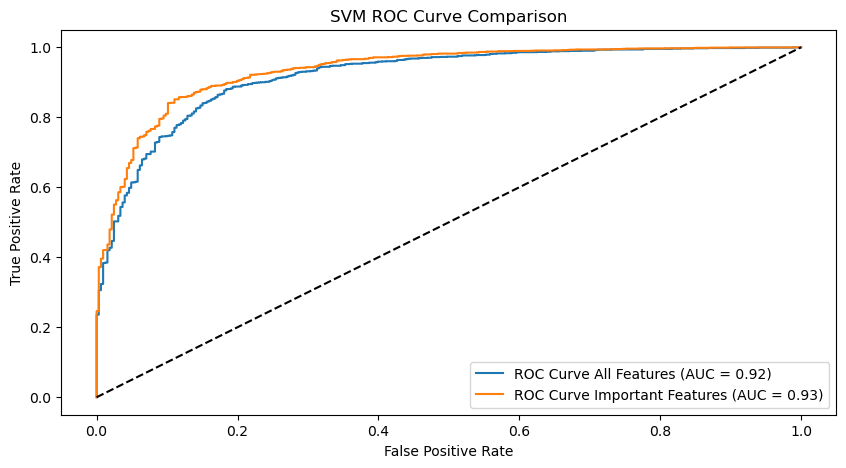

In [10]:
from sklearn.svm import SVC

# Build SVM models
svm_model_all = SVC(probability=True)
svm_model_important = SVC(probability=True)

svm_model_all.fit(X_train_all, y_train_all)
svm_model_important.fit(X_train_important, y_train_important)

# Predictions
svm_y_preds_all = svm_model_all.predict(X_test_all)
svm_y_probs_all = svm_model_all.predict_proba(X_test_all)[:, 1]
svm_y_preds_important = svm_model_important.predict(X_test_important)
svm_y_probs_important = svm_model_important.predict_proba(X_test_important)[:, 1]

# Metrics for SVM
svm_metrics_all = {
    'Accuracy': accuracy_score(y_test_all, svm_y_preds_all),
    'Precision': precision_score(y_test_all, svm_y_preds_all),
    'Recall': recall_score(y_test_all, svm_y_preds_all),
    'F1 Score': f1_score(y_test_all, svm_y_preds_all),
    'ROC AUC': roc_auc_score(y_test_all, svm_y_probs_all)
}

svm_metrics_important = {
    'Accuracy': accuracy_score(y_test_important, svm_y_preds_important),
    'Precision': precision_score(y_test_important, svm_y_preds_important),
    'Recall': recall_score(y_test_important, svm_y_preds_important),
    'F1 Score': f1_score(y_test_important, svm_y_preds_important),
    'ROC AUC': roc_auc_score(y_test_important, svm_y_probs_important)
}

# Print metrics
print("Metrics for SVM Model with All Features:")
print(svm_metrics_all)
print("\nMetrics for SVM Model with Important Features:")
print(svm_metrics_important)

# ROC Curve for SVM
svm_fpr_all, svm_tpr_all, _ = roc_curve(y_test_all, svm_y_probs_all)
svm_fpr_important, svm_tpr_important, _ = roc_curve(y_test_important, svm_y_probs_important)

plt.figure(figsize=(10, 5))
plt.plot(svm_fpr_all, svm_tpr_all, label=f'ROC Curve All Features (AUC = {svm_metrics_all["ROC AUC"]:.2f})')
plt.plot(svm_fpr_important, svm_tpr_important, label=f'ROC Curve Important Features (AUC = {svm_metrics_important["ROC AUC"]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM ROC Curve Comparison')
plt.legend()
plt.show()


Metrics for Gradient Boosting Model with All Features:
{'Accuracy': 0.9580454096742349, 'Precision': 0.9775280898876404, 'Recall': 0.9723529411764706, 'F1 Score': 0.9749336478914774, 'ROC AUC': 0.9876380368098161}

Metrics for Gradient Boosting Model with Important Features:
{'Accuracy': 0.9200394866732478, 'Precision': 0.955568720379147, 'Recall': 0.9488235294117647, 'F1 Score': 0.9521841794569068, 'ROC AUC': 0.9450911223385059}


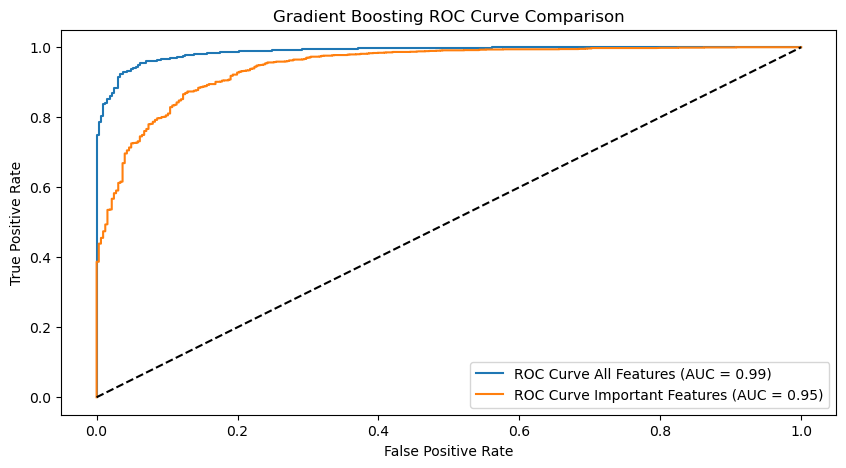

In [11]:
from sklearn.ensemble import GradientBoostingClassifier

# Build Gradient Boosting models
gb_model_all = GradientBoostingClassifier()
gb_model_important = GradientBoostingClassifier()

gb_model_all.fit(X_train_all, y_train_all)
gb_model_important.fit(X_train_important, y_train_important)

# Predictions
gb_y_preds_all = gb_model_all.predict(X_test_all)
gb_y_probs_all = gb_model_all.predict_proba(X_test_all)[:, 1]
gb_y_preds_important = gb_model_important.predict(X_test_important)
gb_y_probs_important = gb_model_important.predict_proba(X_test_important)[:, 1]

# Metrics for Gradient Boosting
gb_metrics_all = {
    'Accuracy': accuracy_score(y_test_all, gb_y_preds_all),
    'Precision': precision_score(y_test_all, gb_y_preds_all),
    'Recall': recall_score(y_test_all, gb_y_preds_all),
    'F1 Score': f1_score(y_test_all, gb_y_preds_all),
    'ROC AUC': roc_auc_score(y_test_all, gb_y_probs_all)
}

gb_metrics_important = {
    'Accuracy': accuracy_score(y_test_important, gb_y_preds_important),
    'Precision': precision_score(y_test_important, gb_y_preds_important),
    'Recall': recall_score(y_test_important, gb_y_preds_important),
    'F1 Score': f1_score(y_test_important, gb_y_preds_important),
    'ROC AUC': roc_auc_score(y_test_important, gb_y_probs_important)
}

# Print metrics
print("Metrics for Gradient Boosting Model with All Features:")
print(gb_metrics_all)
print("\nMetrics for Gradient Boosting Model with Important Features:")
print(gb_metrics_important)

# ROC Curve for Gradient Boosting
gb_fpr_all, gb_tpr_all, _ = roc_curve(y_test_all, gb_y_probs_all)
gb_fpr_important, gb_tpr_important, _ = roc_curve(y_test_important, gb_y_probs_important)

plt.figure(figsize=(10, 5))
plt.plot(gb_fpr_all, gb_tpr_all, label=f'ROC Curve All Features (AUC = {gb_metrics_all["ROC AUC"]:.2f})')
plt.plot(gb_fpr_important, gb_tpr_important, label=f'ROC Curve Important Features (AUC = {gb_metrics_important["ROC AUC"]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Gradient Boosting ROC Curve Comparison')
plt.legend()
plt.show()


Metrics for XGBoost Model with All Features:
{'Accuracy': 0.9664363277393879, 'Precision': 0.9817001180637545, 'Recall': 0.9782352941176471, 'F1 Score': 0.9799646434885091, 'ROC AUC': 0.9926199927823891}

Metrics for XGBoost Model with Important Features:
{'Accuracy': 0.9195459032576505, 'Precision': 0.950733137829912, 'Recall': 0.9535294117647058, 'F1 Score': 0.952129221732746, 'ROC AUC': 0.9398736918080117}


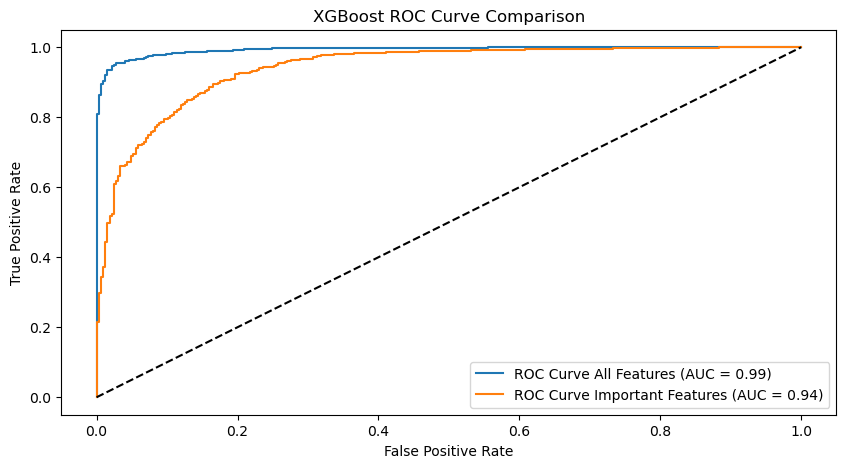

In [12]:
from xgboost import XGBClassifier

# Build XGBoost models
xgb_model_all = XGBClassifier(eval_metric='logloss')
xgb_model_important = XGBClassifier(eval_metric='logloss')

xgb_model_all.fit(X_train_all, y_train_all)
xgb_model_important.fit(X_train_important, y_train_important)

# Predictions
xgb_y_preds_all = xgb_model_all.predict(X_test_all)
xgb_y_probs_all = xgb_model_all.predict_proba(X_test_all)[:, 1]
xgb_y_preds_important = xgb_model_important.predict(X_test_important)
xgb_y_probs_important = xgb_model_important.predict_proba(X_test_important)[:, 1]

# Metrics for XGBoost
xgb_metrics_all = {
    'Accuracy': accuracy_score(y_test_all, xgb_y_preds_all),
    'Precision': precision_score(y_test_all, xgb_y_preds_all),
    'Recall': recall_score(y_test_all, xgb_y_preds_all),
    'F1 Score': f1_score(y_test_all, xgb_y_preds_all),
    'ROC AUC': roc_auc_score(y_test_all, xgb_y_probs_all)
}

xgb_metrics_important = {
    'Accuracy': accuracy_score(y_test_important, xgb_y_preds_important),
    'Precision': precision_score(y_test_important, xgb_y_preds_important),
    'Recall': recall_score(y_test_important, xgb_y_preds_important),
    'F1 Score': f1_score(y_test_important, xgb_y_preds_important),
    'ROC AUC': roc_auc_score(y_test_important, xgb_y_probs_important)
}

# Print metrics
print("Metrics for XGBoost Model with All Features:")
print(xgb_metrics_all)
print("\nMetrics for XGBoost Model with Important Features:")
print(xgb_metrics_important)

# ROC Curve for XGBoost
xgb_fpr_all, xgb_tpr_all, _ = roc_curve(y_test_all, xgb_y_probs_all)
xgb_fpr_important, xgb_tpr_important, _ = roc_curve(y_test_important, xgb_y_probs_important)

plt.figure(figsize=(10, 5))
plt.plot(xgb_fpr_all, xgb_tpr_all, label=f'ROC Curve All Features (AUC = {xgb_metrics_all["ROC AUC"]:.2f})')
plt.plot(xgb_fpr_important, xgb_tpr_important, label=f'ROC Curve Important Features (AUC = {xgb_metrics_important["ROC AUC"]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost ROC Curve Comparison')
plt.legend()
plt.show()


In [13]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# Define the model
xgb = XGBClassifier(eval_metric='logloss')

# Define the parameter grid
param_grid = {
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.5, 0.75, 1.0],
    'min_child_weight': [1, 3, 5]
}

# Set up the grid search
grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, scoring='accuracy', cv=3, verbose=2)

# Fit grid search
best_model = grid_search.fit(X_train_all, y_train_all)

# Get the best model
print("Best parameters found: ", grid_search.best_params_)
print("Best accuracy found: ", grid_search.best_score_)


Fitting 3 folds for each of 243 candidates, totalling 729 fits
[CV] END learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.5; total time=   0.1s
[CV] END learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.5; total time=   0.1s
[CV] END learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.5; total time=   0.1s
[CV] END learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.75; total time=   0.0s
[CV] END learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.75; total time=   0.0s
[CV] END learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.75; total time=   0.1s
[CV] END learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=1.0; total time=   0.1s
[CV] END learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=1.0; total time=   0.1s
[CV] END learning_rate

In [14]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Define the optimized model
xgb_optimized = XGBClassifier(
    learning_rate=0.1,
    max_depth=7,
    min_child_weight=1,
    n_estimators=300,
    subsample=0.75,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Fit the model on the training data
xgb_optimized.fit(X_train_all, y_train_all)

# Load the validation data
validation_data = pd.read_csv(validation_data_path)
X_validation = validation_data.drop(columns=['Attrition_Flag'])
y_validation = validation_data['Attrition_Flag']

# Predict on the validation set
y_preds_validation = xgb_optimized.predict(X_validation)
y_probs_validation = xgb_optimized.predict_proba(X_validation)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_validation, y_preds_validation)
precision = precision_score(y_validation, y_preds_validation)
recall = recall_score(y_validation, y_preds_validation)
f1 = f1_score(y_validation, y_preds_validation)
roc_auc = roc_auc_score(y_validation, y_probs_validation)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"ROC AUC: {roc_auc}")


/opt/anaconda3/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [08:57:33] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy: 0.9674074074074074
Precision: 0.9794600938967136
Recall: 0.981764705882353
F1 Score: 0.9806110458284372
ROC AUC: 0.9912778280542986


In [15]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

xgb_optimized = XGBClassifier(
    learning_rate=0.1,
    max_depth=7,
    min_child_weight=1,
    n_estimators=300,
    subsample=0.75,
    eval_metric='logloss'
)

# Perform cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
cv_scores = cross_val_score(
    xgb_optimized, X_train_all, y_train_all, cv=cv, scoring='accuracy', n_jobs=-1
)

# Output the cross-validation scores, mean, and standard deviation
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV score: {cv_scores.mean()}")
print(f"Standard Deviation of CV scores: {cv_scores.std()}")

Cross-validation scores: [0.98186275 0.9872549  0.98480392 0.98529412 0.98431373]
Mean CV score: 0.9847058823529412
Standard Deviation of CV scores: 0.0017372593281048735


In [16]:
import pandas as pd

# Define metrics for each model with all features
model_metrics = {
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'SVM',
        'Gradient Boosting',
        'XGBoost'
    ],
    'Accuracy (%)': [
        metrics_all['Accuracy'] * 100,
        dt_metrics_all['Accuracy'] * 100,
        rf_metrics_all['Accuracy'] * 100,
        svm_metrics_all['Accuracy'] * 100,
        gb_metrics_all['Accuracy'] * 100,
        xgb_metrics_all['Accuracy'] * 100
    ],
    'Precision (%)': [
        metrics_all['Precision'] * 100,
        dt_metrics_all['Precision'] * 100,
        rf_metrics_all['Precision'] * 100,
        svm_metrics_all['Precision'] * 100,
        gb_metrics_all['Precision'] * 100,
        xgb_metrics_all['Precision'] * 100
    ],
    'Recall (%)': [
        metrics_all['Recall'] * 100,
        dt_metrics_all['Recall'] * 100,
        rf_metrics_all['Recall'] * 100,
        svm_metrics_all['Recall'] * 100,
        gb_metrics_all['Recall'] * 100,
        xgb_metrics_all['Recall'] * 100
    ],
    'F1 Score (%)': [
        metrics_all['F1 Score'] * 100,
        dt_metrics_all['F1 Score'] * 100,
        rf_metrics_all['F1 Score'] * 100,
        svm_metrics_all['F1 Score'] * 100,
        gb_metrics_all['F1 Score'] * 100,
        xgb_metrics_all['F1 Score'] * 100
    ],
    'ROC AUC (%)': [
        metrics_all['ROC AUC'] * 100,
        dt_metrics_all['ROC AUC'] * 100,
        rf_metrics_all['ROC AUC'] * 100,
        svm_metrics_all['ROC AUC'] * 100,
        gb_metrics_all['ROC AUC'] * 100,
        xgb_metrics_all['ROC AUC'] * 100
    ]
}

# Create a dataframe from the dictionary
metrics_df = pd.DataFrame(model_metrics)

# Sort the dataframe by Accuracy in descending order
metrics_df_sorted = metrics_df.sort_values(by='Accuracy (%)', ascending=False)

# Display the sorted DataFrame
metrics_df_sorted


,Model,Accuracy (%),Precision (%),Recall (%),F1 Score (%),ROC AUC (%)
5,XGBoost,96.643633,98.170012,97.823529,97.996464,99.261999
2,Random Forest,95.952616,97.476526,97.705882,97.591069,98.643360
4,Gradient Boosting,95.804541,97.752809,97.235294,97.493365,98.763804
1,Decision Tree,92.991115,96.369048,95.235294,95.798817,88.261819
3,SVM,88.302073,94.904850,90.941176,92.880745,91.807560
0,Logistic Regression,85.784798,95.784695,86.882353,91.116595,91.524901
